In [ ]:
#@title 0) setup
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import itertools, random, time
import copy

# Reproducibility
SEED = 42
def resetRandom():
  torch.manual_seed(SEED)
  np.random.seed(SEED)
  random.seed(SEED)
resetRandom()

# training time optimization
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 1) MLP: A * B % C (A,B between 0..99, C 0..19)

## 1.1) Dataset

In [ ]:
def one_hot(n, num_classes=100):
    # One-hot encode a single integer.
    v = np.zeros(num_classes, dtype=np.float32)
    v[n] = 1.0
    return v

# ── Generate all 10,000 input pairs ──
pairs = list(itertools.product(range(100), range(100), range(19)))
random.shuffle(pairs)

X_all, y_all = [], []
for a, b, c in pairs:
    x = np.concatenate([one_hot(a), one_hot(b), one_hot(c, 19)])   # 220-dim
    y = (a * b) % (c+1)
    X_all.append(x)
    y_all.append(y)

X_all = np.array(X_all)
y_all = np.array(y_all)

# 80-20 split
split = int(0.8 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

# DataLoaders — mini-batch (full-batch would be 8K samples)
BATCH_SIZE = 256
train_ds = TensorDataset(torch.tensor(X_train).to(device), torch.tensor(y_train, dtype=torch.long).to(device))
test_ds  = TensorDataset(torch.tensor(X_test).to(device),  torch.tensor(y_test, dtype=torch.long).to(device))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Train: {len(train_ds):,} samples  |  Test: {len(test_ds):,} samples")
print(f"Input dim: {X_train.shape[1]}  |  Output classes: {len(np.unique(y_all))}")
print(f"Label distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")

Train: 152,000 samples  |  Test: 38,000 samples
Input dim: 219  |  Output classes: 19
Label distribution (train): {np.int64(0): np.int64(51411), np.int64(1): np.int64(11977), np.int64(2): np.int64(14363), np.int64(3): np.int64(10413), np.int64(4): np.int64(11615), np.int64(5): np.int64(6717), np.int64(6): np.int64(10053), np.int64(7): np.int64(4823), np.int64(8): np.int64(6869), np.int64(9): np.int64(4650), np.int64(10): np.int64(4769), np.int64(11): np.int64(2542), np.int64(12): np.int64(4452), np.int64(13): np.int64(1747), np.int64(14): np.int64(2023), np.int64(15): np.int64(1374), np.int64(16): np.int64(1254), np.int64(17): np.int64(538), np.int64(18): np.int64(410)}


## 1.2) DNN: 16x2 growing & shrinking FFN w/ Residuals + Normalization

In [ ]:
class DNN(nn.Module):
    def __init__(self, norm_type=None, is_post_norm=False):
        super().__init__()
        self.is_post_norm = is_post_norm
        hidden_dim = 128
        self.proj_in = nn.Linear(219, hidden_dim)
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(16):
            self.layers.append(
                nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim * 2),
                    nn.ReLU(),
                    nn.Linear(hidden_dim * 2, hidden_dim))
                )
            if norm_type is not None:
                self.norms.append(norm_type(hidden_dim))
            else:
                self.norms.append(nn.Identity())
        self.proj_out = nn.Linear(hidden_dim, 19)

    def forward(self, x):

        for layer, norm in zip(self.layers, self.norms):
            if self.is_post_norm:
                x = norm(x + layer(x))
            else:
                x = x + layer(norm(x))
        return self.proj_out(x)

model = DNN().to(device)
print(model)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Per-layer shapes:")
for name, param in model.named_parameters():
    if "weight" in name:
        print(f"  {name:30s}  {str(list(param.shape)):>15s}  ({param.numel():>6,} params)")


DNN(
  (proj_in): Linear(in_features=219, out_features=128, bias=True)
  (layers): ModuleList(
    (0-15): 16 x Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (norms): ModuleList(
    (0-15): 16 x Identity()
  )
  (proj_out): Linear(in_features=128, out_features=20, bias=True)
)
Total parameters: 1,085,460
Per-layer shapes:
  proj_in.weight                       [128, 219]  (28,032 params)
  layers.0.0.weight                    [256, 128]  (32,768 params)
  layers.0.2.weight                    [128, 256]  (32,768 params)
  layers.1.0.weight                    [256, 128]  (32,768 params)
  layers.1.2.weight                    [128, 256]  (32,768 params)
  layers.2.0.weight                    [256, 128]  (32,768 params)
  layers.2.2.weight                    [128, 256]  (32,768 params)
  layers.3.0.weight                    [256, 128]  (32,768 params)
  layers.3.2.we

## 1.3) Train


In [ ]:
# ── Hyperparameters ──
LR = 1e-3
WEIGHT_DECAY = 0.001
MAX_EPOCHS = 200

all_runs = []  # global: stores {"name", "converged_epoch", "history"} per run

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += len(yb)
    return total_loss / total, correct / total

def train(run_name="", norm_type=None, is_post_norm=False):
    # Reset model and optimizer
    global model, optimizer, criterion, history
    resetRandom()
    model = DNN(norm_type=norm_type, is_post_norm=is_post_norm).to(device)
    model = torch.compile(model)
    def _init_weights(m):
        if hasattr(m, 'weight') and m.weight.dim() >= 2:
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    model.apply(_init_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    # Reset logging
    history = {
        "epoch": [], "train_loss": [], "test_loss": [],
        "train_acc": [], "test_acc": []
    }

    print(f"{'='*60}")
    print(f"  🚀 Run: {run_name}")
    print(f"{'='*60}")

    # ── Training loop ──
    reached_100 = False

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(train_loader)
        test_loss, test_acc   = evaluate(test_loader)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch:>6d} | "
              f"Train loss {train_loss:.4f}  acc {train_acc:.1%} | "
              f"Test loss {test_loss:.4f}  acc {test_acc:.1%}")

        if test_acc == 1.00 and train_acc == 1.00:
            print(f"{'='*60}")
            print(f"  ✅ 100% test accuracy reached at epoch {epoch}!")
            print(f"  📊 Final — Train: {train_acc:.2%}  Test: {test_acc:.2%}")
            print(f"{'='*60}")
            reached_100 = True
            break

    if not reached_100:
        print(f"⚠️  Did not reach 100% in {MAX_EPOCHS} epochs.")
        print(f"    Final test acc: {history['test_acc'][-1]:.1%}")

    converged_epoch = epoch if reached_100 else None
    all_runs.append({"name": run_name,
                     "converged_epoch": converged_epoch,
                     "history": dict(history),
                     "model": copy.deepcopy(model)})

# 2) Baseline: no normalization

In [ ]:
train(run_name="no normalization")

  🚀 Run: no normalization
Epoch      1 | Train loss 2.4955  acc 30.8% | Test loss 2.5556  acc 30.0%
Epoch      2 | Train loss 2.2187  acc 28.8% | Test loss 2.2666  acc 28.0%
Epoch      3 | Train loss 2.1026  acc 33.5% | Test loss 2.1670  acc 32.3%
Epoch      4 | Train loss 1.9265  acc 35.2% | Test loss 1.9882  acc 33.7%
Epoch      5 | Train loss 1.8471  acc 37.3% | Test loss 1.9187  acc 34.9%
Epoch      6 | Train loss 1.6706  acc 42.2% | Test loss 1.7563  acc 39.7%
Epoch      7 | Train loss 1.4884  acc 47.4% | Test loss 1.5761  acc 45.1%
Epoch      8 | Train loss 1.2619  acc 52.4% | Test loss 1.3350  acc 49.9%
Epoch      9 | Train loss 1.1502  acc 54.4% | Test loss 1.2114  acc 52.4%
Epoch     10 | Train loss 1.0995  acc 55.3% | Test loss 1.1520  acc 53.3%
Epoch     11 | Train loss 1.0704  acc 55.6% | Test loss 1.1171  acc 53.7%
Epoch     12 | Train loss 1.0747  acc 55.5% | Test loss 1.1142  acc 53.9%
Epoch     13 | Train loss 1.0609  acc 55.4% | Test loss 1.0962  acc 53.9%
Epoch     14

# 3) Pre-norm RMSNorm

In [ ]:
train(run_name="pre-norm RMSNorm", norm_type=nn.RMSNorm)

  🚀 Run: pre-norm RMSNorm
Epoch      1 | Train loss 1.3267  acc 52.3% | Test loss 1.3792  acc 50.8%
Epoch      2 | Train loss 1.1334  acc 55.2% | Test loss 1.1627  acc 53.9%
Epoch      3 | Train loss 1.1164  acc 54.9% | Test loss 1.1492  acc 53.5%
Epoch      4 | Train loss 0.9784  acc 60.1% | Test loss 1.0065  acc 58.5%
Epoch      5 | Train loss 0.9388  acc 61.5% | Test loss 0.9653  acc 60.1%
Epoch      6 | Train loss 0.9277  acc 61.9% | Test loss 0.9544  acc 60.4%
Epoch      7 | Train loss 0.8232  acc 68.0% | Test loss 0.8451  acc 66.9%
Epoch      8 | Train loss 0.7484  acc 71.4% | Test loss 0.7683  acc 70.4%
Epoch      9 | Train loss 0.7160  acc 72.3% | Test loss 0.7361  acc 71.0%
Epoch     10 | Train loss 0.6757  acc 73.3% | Test loss 0.6962  acc 72.6%
Epoch     11 | Train loss 0.6211  acc 77.0% | Test loss 0.6441  acc 75.8%
Epoch     12 | Train loss 0.5361  acc 81.1% | Test loss 0.5542  acc 80.2%
Epoch     13 | Train loss 0.4969  acc 82.7% | Test loss 0.5150  acc 82.1%
Epoch     14

# 4) Post-norm RMSNorm

In [ ]:
train(run_name="post-norm RMSNorm", norm_type=nn.RMSNorm, is_post_norm=True)

  🚀 Run: post-norm RMSNorm
Epoch      1 | Train loss 1.9102  acc 35.6% | Test loss 1.9218  acc 35.5%
Epoch      2 | Train loss 1.7565  acc 42.4% | Test loss 1.7624  acc 42.3%
Epoch      3 | Train loss 1.8282  acc 38.7% | Test loss 1.8343  acc 38.6%
Epoch      4 | Train loss 1.5656  acc 45.1% | Test loss 1.5741  acc 44.9%
Epoch      5 | Train loss 2.1197  acc 34.5% | Test loss 2.1229  acc 34.1%
Epoch      6 | Train loss 2.1693  acc 33.8% | Test loss 2.1732  acc 33.6%
Epoch      7 | Train loss 2.1661  acc 33.8% | Test loss 2.1717  acc 33.2%
Epoch      8 | Train loss 2.3028  acc 35.1% | Test loss 2.3090  acc 34.8%
Epoch      9 | Train loss 2.1946  acc 34.7% | Test loss 2.1996  acc 34.4%
Epoch     10 | Train loss 2.2021  acc 33.8% | Test loss 2.2034  acc 33.6%
Epoch     11 | Train loss 2.2009  acc 33.8% | Test loss 2.2022  acc 33.6%
Epoch     12 | Train loss 2.1985  acc 33.8% | Test loss 2.1985  acc 33.6%
Epoch     13 | Train loss 2.2013  acc 33.8% | Test loss 2.2019  acc 33.6%
Epoch     1

# 5) Pre-norm LayerNorm

In [ ]:
train(run_name="pre-norm LayerNorm", norm_type=nn.LayerNorm)

  🚀 Run: pre-norm LayerNorm


W0401 02:11:17.694000 1428 torch/_dynamo/convert_frame.py:1676] [0/8] torch._dynamo hit config.recompile_limit (8)
W0401 02:11:17.694000 1428 torch/_dynamo/convert_frame.py:1676] [0/8]    function: 'forward' (/tmp/ipykernel_1428/756787679.py:22)
W0401 02:11:17.694000 1428 torch/_dynamo/convert_frame.py:1676] [0/8]    last reason: 0/7: GLOBAL_STATE changed: grad_mode 
W0401 02:11:17.694000 1428 torch/_dynamo/convert_frame.py:1676] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0401 02:11:17.694000 1428 torch/_dynamo/convert_frame.py:1676] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/compile/programming_model.recompilation.html


Epoch      1 | Train loss 1.3583  acc 51.9% | Test loss 1.4216  acc 50.3%
Epoch      2 | Train loss 1.1250  acc 55.4% | Test loss 1.1654  acc 53.9%
Epoch      3 | Train loss 1.0746  acc 55.8% | Test loss 1.1165  acc 54.2%
Epoch      4 | Train loss 0.9482  acc 61.5% | Test loss 0.9882  acc 59.6%
Epoch      5 | Train loss 0.9484  acc 61.9% | Test loss 0.9844  acc 59.9%
Epoch      6 | Train loss 0.8913  acc 64.6% | Test loss 0.9286  acc 62.7%
Epoch      7 | Train loss 0.7548  acc 71.1% | Test loss 0.7811  acc 69.9%
Epoch      8 | Train loss 0.6886  acc 73.8% | Test loss 0.7131  acc 72.8%
Epoch      9 | Train loss 0.5933  acc 77.7% | Test loss 0.6151  acc 76.5%
Epoch     10 | Train loss 0.5861  acc 77.8% | Test loss 0.6057  acc 76.9%
Epoch     11 | Train loss 0.6035  acc 77.1% | Test loss 0.6273  acc 76.2%
Epoch     12 | Train loss 0.5858  acc 77.9% | Test loss 0.6101  acc 76.8%
Epoch     13 | Train loss 0.5725  acc 78.8% | Test loss 0.6032  acc 77.5%
Epoch     14 | Train loss 0.4973  acc 

# 6) Post-norm LayerNorm

In [ ]:
train(run_name="post-norm LayerNorm", norm_type=nn.LayerNorm, is_post_norm=True)

  🚀 Run: post-norm LayerNorm
Epoch      1 | Train loss 1.8853  acc 34.9% | Test loss 1.8997  acc 34.6%
Epoch      2 | Train loss 2.2011  acc 30.4% | Test loss 2.2009  acc 30.7%
Epoch      3 | Train loss 2.2987  acc 33.8% | Test loss 2.3050  acc 33.6%
Epoch      4 | Train loss 2.2935  acc 33.8% | Test loss 2.2998  acc 33.6%
Epoch      5 | Train loss 2.2921  acc 33.8% | Test loss 2.2981  acc 33.6%
Epoch      6 | Train loss 2.2961  acc 33.8% | Test loss 2.3027  acc 33.6%
Epoch      7 | Train loss 2.2998  acc 33.8% | Test loss 2.3063  acc 33.6%
Epoch      8 | Train loss 2.3064  acc 33.8% | Test loss 2.3122  acc 33.6%
Epoch      9 | Train loss 2.3027  acc 33.8% | Test loss 2.3082  acc 33.6%
Epoch     10 | Train loss 2.3022  acc 33.8% | Test loss 2.3091  acc 33.6%
Epoch     11 | Train loss 2.3019  acc 33.8% | Test loss 2.3082  acc 33.6%
Epoch     12 | Train loss 2.3007  acc 33.8% | Test loss 2.3062  acc 33.6%
Epoch     13 | Train loss 2.2471  acc 33.8% | Test loss 2.2527  acc 33.6%
Epoch    

# 7) Pre-norm BatchNorm

In [ ]:
train(run_name="pre-norm BatchNorm", norm_type=nn.BatchNorm1d)

  🚀 Run: pre-norm BatchNorm
Epoch      1 | Train loss 1.3752  acc 50.1% | Test loss 1.4502  acc 47.7%
Epoch      2 | Train loss 1.0895  acc 55.8% | Test loss 1.1431  acc 53.2%
Epoch      3 | Train loss 1.0449  acc 56.6% | Test loss 1.1034  acc 53.7%
Epoch      4 | Train loss 1.0303  acc 57.5% | Test loss 1.0940  acc 53.6%
Epoch      5 | Train loss 0.9151  acc 63.1% | Test loss 0.9761  acc 59.3%
Epoch      6 | Train loss 0.8810  acc 65.3% | Test loss 0.9479  acc 61.4%
Epoch      7 | Train loss 0.7236  acc 72.9% | Test loss 0.7676  acc 70.7%
Epoch      8 | Train loss 0.6526  acc 75.2% | Test loss 0.6964  acc 72.8%
Epoch      9 | Train loss 0.5583  acc 80.5% | Test loss 0.5959  acc 78.9%
Epoch     10 | Train loss 0.4915  acc 82.9% | Test loss 0.5169  acc 82.1%
Epoch     11 | Train loss 0.4844  acc 83.2% | Test loss 0.5103  acc 82.2%
Epoch     12 | Train loss 0.4836  acc 83.3% | Test loss 0.5090  acc 82.2%
Epoch     13 | Train loss 0.4748  acc 83.5% | Test loss 0.5083  acc 82.2%
Epoch     

# 8) Post-norm BatchNorm

In [ ]:
train(run_name="post-norm BatchNorm", norm_type=nn.BatchNorm1d, is_post_norm=True)

  🚀 Run: post-norm BatchNorm
Epoch      1 | Train loss 1.2363  acc 51.2% | Test loss 1.2520  acc 51.0%
Epoch      2 | Train loss 1.0516  acc 54.5% | Test loss 1.0548  acc 54.2%
Epoch      3 | Train loss 1.0453  acc 54.4% | Test loss 1.0485  acc 54.3%
Epoch      4 | Train loss 1.0379  acc 54.6% | Test loss 1.0403  acc 54.3%
Epoch      5 | Train loss 1.0368  acc 54.6% | Test loss 1.0392  acc 54.1%
Epoch      6 | Train loss 1.0615  acc 54.3% | Test loss 1.0629  acc 54.2%
Epoch      7 | Train loss 1.0356  acc 54.5% | Test loss 1.0357  acc 54.3%
Epoch      8 | Train loss 1.0298  acc 54.6% | Test loss 1.0296  acc 54.6%
Epoch      9 | Train loss 1.0326  acc 54.6% | Test loss 1.0332  acc 54.5%
Epoch     10 | Train loss 1.0303  acc 54.6% | Test loss 1.0318  acc 54.4%
Epoch     11 | Train loss 1.0451  acc 53.9% | Test loss 1.0458  acc 53.9%
Epoch     12 | Train loss 1.0254  acc 54.6% | Test loss 1.0265  acc 54.5%
Epoch     13 | Train loss 1.0401  acc 54.6% | Test loss 1.0413  acc 54.5%
Epoch    

# 9) Loss + Accuracy across runs

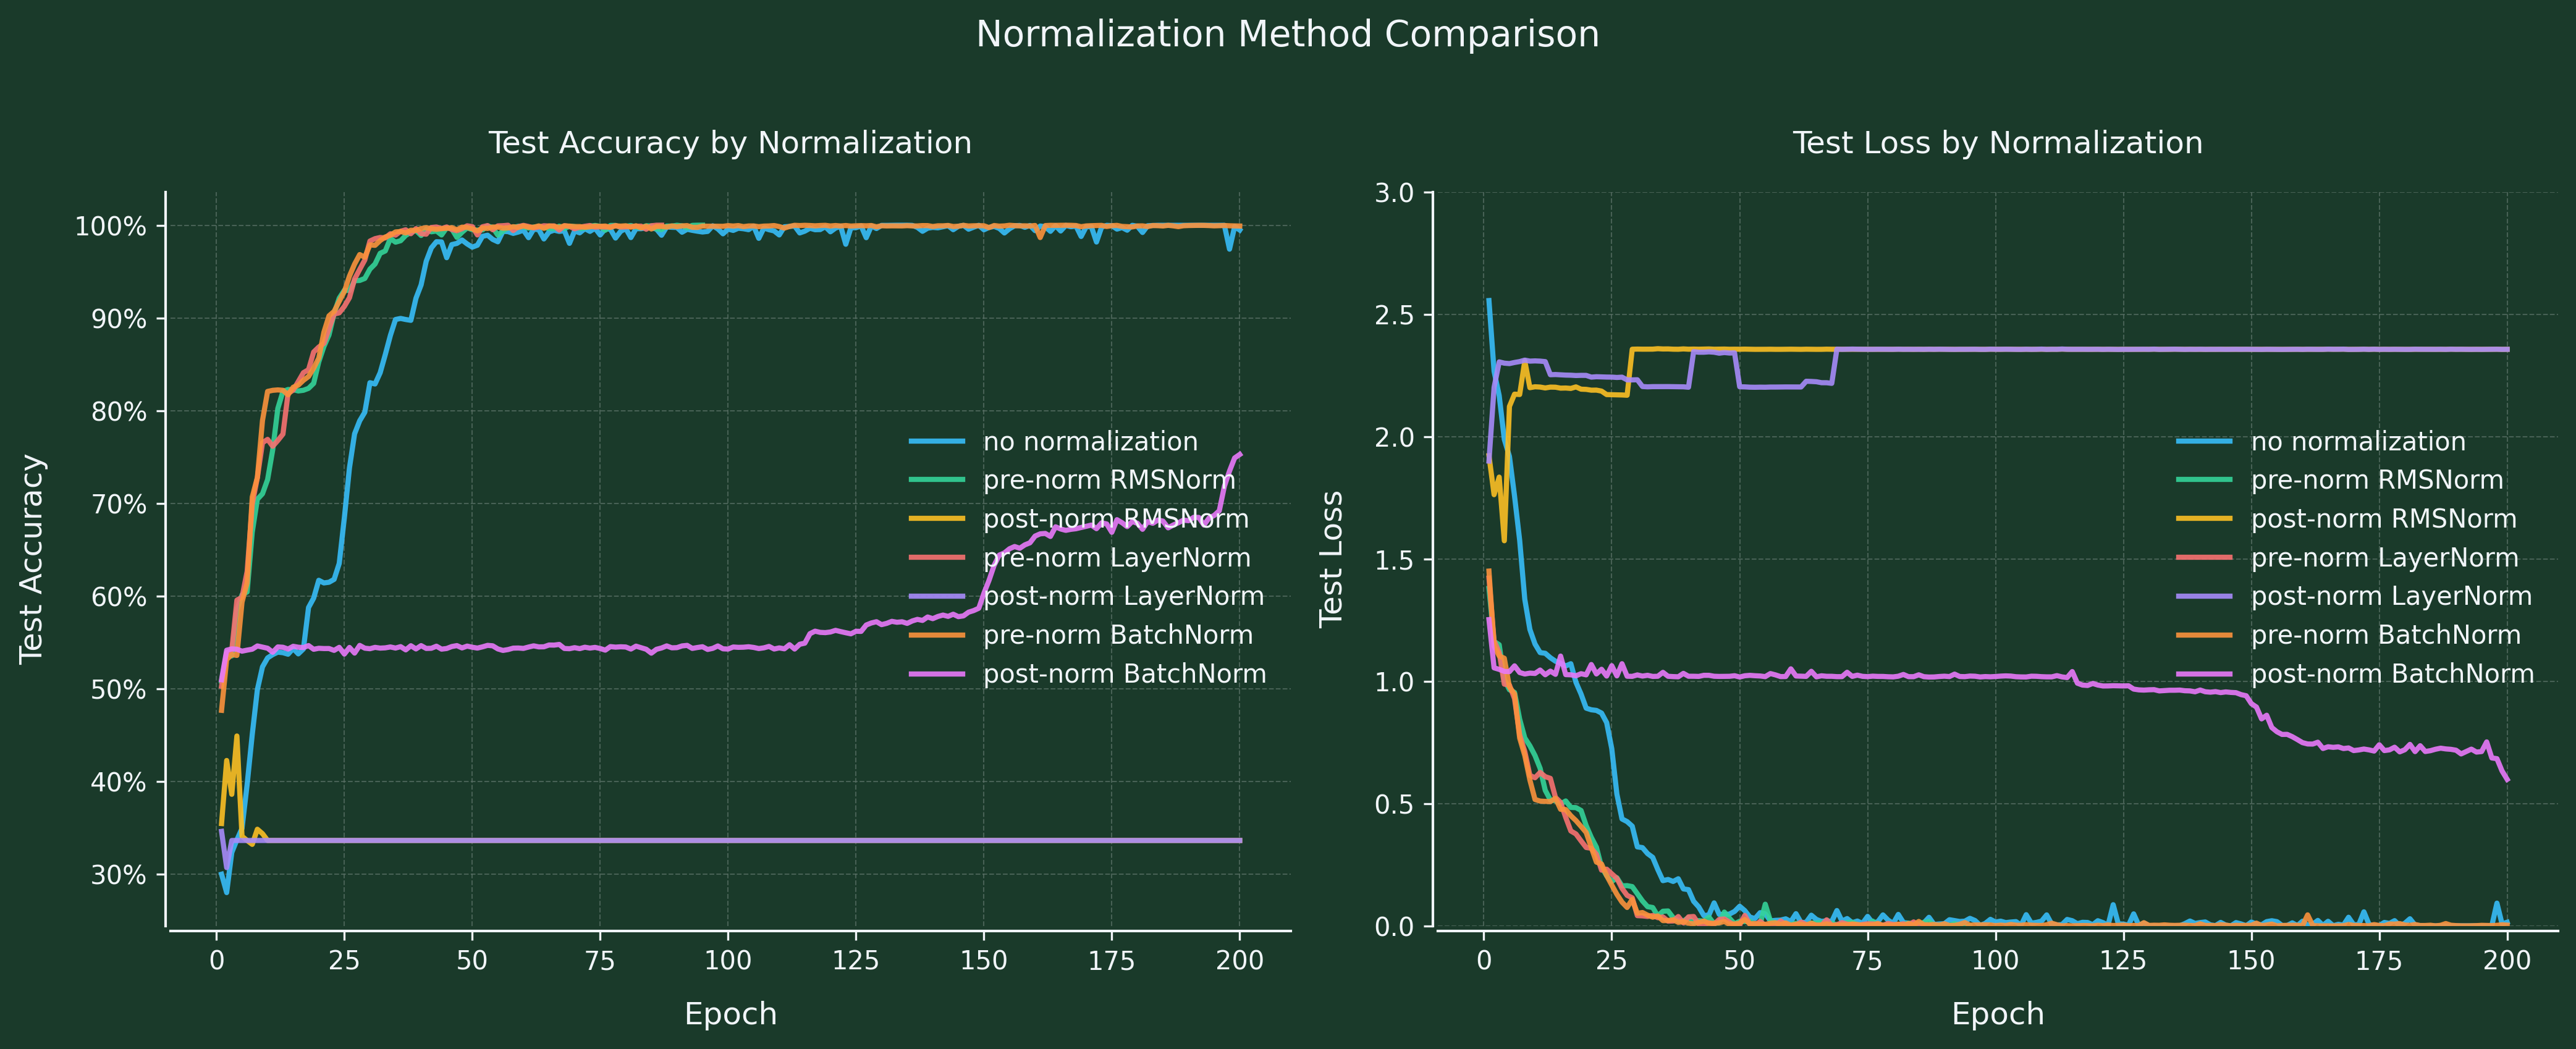


Run                  Converged Epoch     
----------------------------------------
pre-norm LayerNorm   87                  
pre-norm RMSNorm     95                  
no normalization     Did not converge    
post-norm RMSNorm    Did not converge    
post-norm LayerNorm  Did not converge    
pre-norm BatchNorm   Did not converge    
post-norm BatchNorm  Did not converge    


In [ ]:
#@title Visualize
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import logging
import matplotlib.ticker as ticker

# Suppress missing font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Prefer the deployment font when available, otherwise fall back to common sans-serif fonts
font_candidates = ['Inter', 'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['font.family'] = font_candidates
font_path = 'fonts/Inter-Regular.ttf'
try:
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
except Exception:
    pass

# Set styling for all text and lines
plt.rcParams['text.color'] = '#F1F5F9'
plt.rcParams['axes.labelcolor'] = '#F1F5F9'
plt.rcParams['xtick.color'] = '#F1F5F9'
plt.rcParams['ytick.color'] = '#F1F5F9'
plt.rcParams['axes.edgecolor'] = '#F1F5F9'

# Grid styling
plt.rcParams['grid.color'] = '#5B7268'
plt.rcParams['grid.alpha'] = 0.7

def _coplot_luminance_from_rgba(rgba):
    r, g, b = mcolors.to_rgb(rgba)
    def _linear(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * _linear(r) + 0.7152 * _linear(g) + 0.0722 * _linear(b)

def _coplot_text_color_for_rgba(rgba, preferred='#F1F5F9'):
    try:
        preferred_l = _coplot_luminance_from_rgba(mcolors.to_rgba(preferred))
        bg_l = _coplot_luminance_from_rgba(rgba)
        lighter = max(preferred_l, bg_l)
        darker = min(preferred_l, bg_l)
        ratio = (lighter + 0.05) / (darker + 0.05)
        if ratio >= 4.5:
            return preferred
    except Exception:
        pass
    bg_l = _coplot_luminance_from_rgba(rgba)
    return '#111111' if bg_l > 0.5 else '#FFFFFF'

# Create figure and axis with publication-quality settings
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)
fig.patch.set_facecolor('#1A3A2A')

# Distinct bright colors for dark background (modified to keep runs distinguishable)
colors = ["#38BDF8", "#34D399", "#FBBF24", "#F87171", "#A78BFA", "#FB923C", "#E879F9"]
line_styles = ["-","--",":","-."]
marker_styles = ["o","s","^","D"]

for idx, run in enumerate(all_runs):
    h = run["history"]

    line_style = line_styles[idx % len(line_styles)] if False else '-'
    marker_style = marker_styles[idx % len(marker_styles)] if False else ''

    # Plot accuracy
    axes[0].plot(h["epoch"], h["test_acc"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2,
                 linestyle=line_style, marker=marker_style, alpha=0.9)

    # Plot loss
    axes[1].plot(h["epoch"], h["test_loss"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2,
                 linestyle=line_style, marker=marker_style, alpha=0.9)

# Apply custom styling to both axes
for ax in axes:
    ax.set_facecolor('#1A3A2A')
    ax.set_xlabel('Epoch', fontsize=12, labelpad=10, color='#F1F5F9')

    # Force integer epochs
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Add grid
    ax.grid(axis='both', alpha=0.7, color='#5B7268', linestyle='--', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_color('#F1F5F9')
    ax.spines['left'].set_color('#F1F5F9')

    # Adjust spine positions
    ax.spines['left'].set_position(('outward', 2))
    ax.spines['bottom'].set_position(('outward', 2))

    # Add legend
    ax.legend(frameon=False, fontsize=10)

# Specific titles and labels
axes[0].set_ylabel('Test Accuracy', fontsize=12, color='#F1F5F9', labelpad=10)
axes[0].set_title('Test Accuracy by Normalization', color='#F1F5F9', pad=15)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

axes[1].set_ylabel('Test Loss', fontsize=12, color='#F1F5F9', labelpad=10)
axes[1].set_title('Test Loss by Normalization', color='#F1F5F9', pad=15)
axes[1].set_yscale('linear')
axes[1].set_ylim(top=3.0)
axes[1].set_ylim(bottom=0.0)
axes[1].yaxis.set_major_formatter(ticker.ScalarFormatter())

# Global title
plt.suptitle("Normalization Method Comparison", fontsize=14, y=1.02, color='#F1F5F9')

# Tight layout
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Run':<20s} {'Converged Epoch':<20s}")
print("-" * 40)
for run in sorted(all_runs, key=lambda x: (x['converged_epoch'] is None, x['converged_epoch'])):
    ep = run["converged_epoch"]
    print(f"{run['name']:<20s} {str(ep) if ep else 'Did not converge':<20s}")

# 10) Activation values visualized

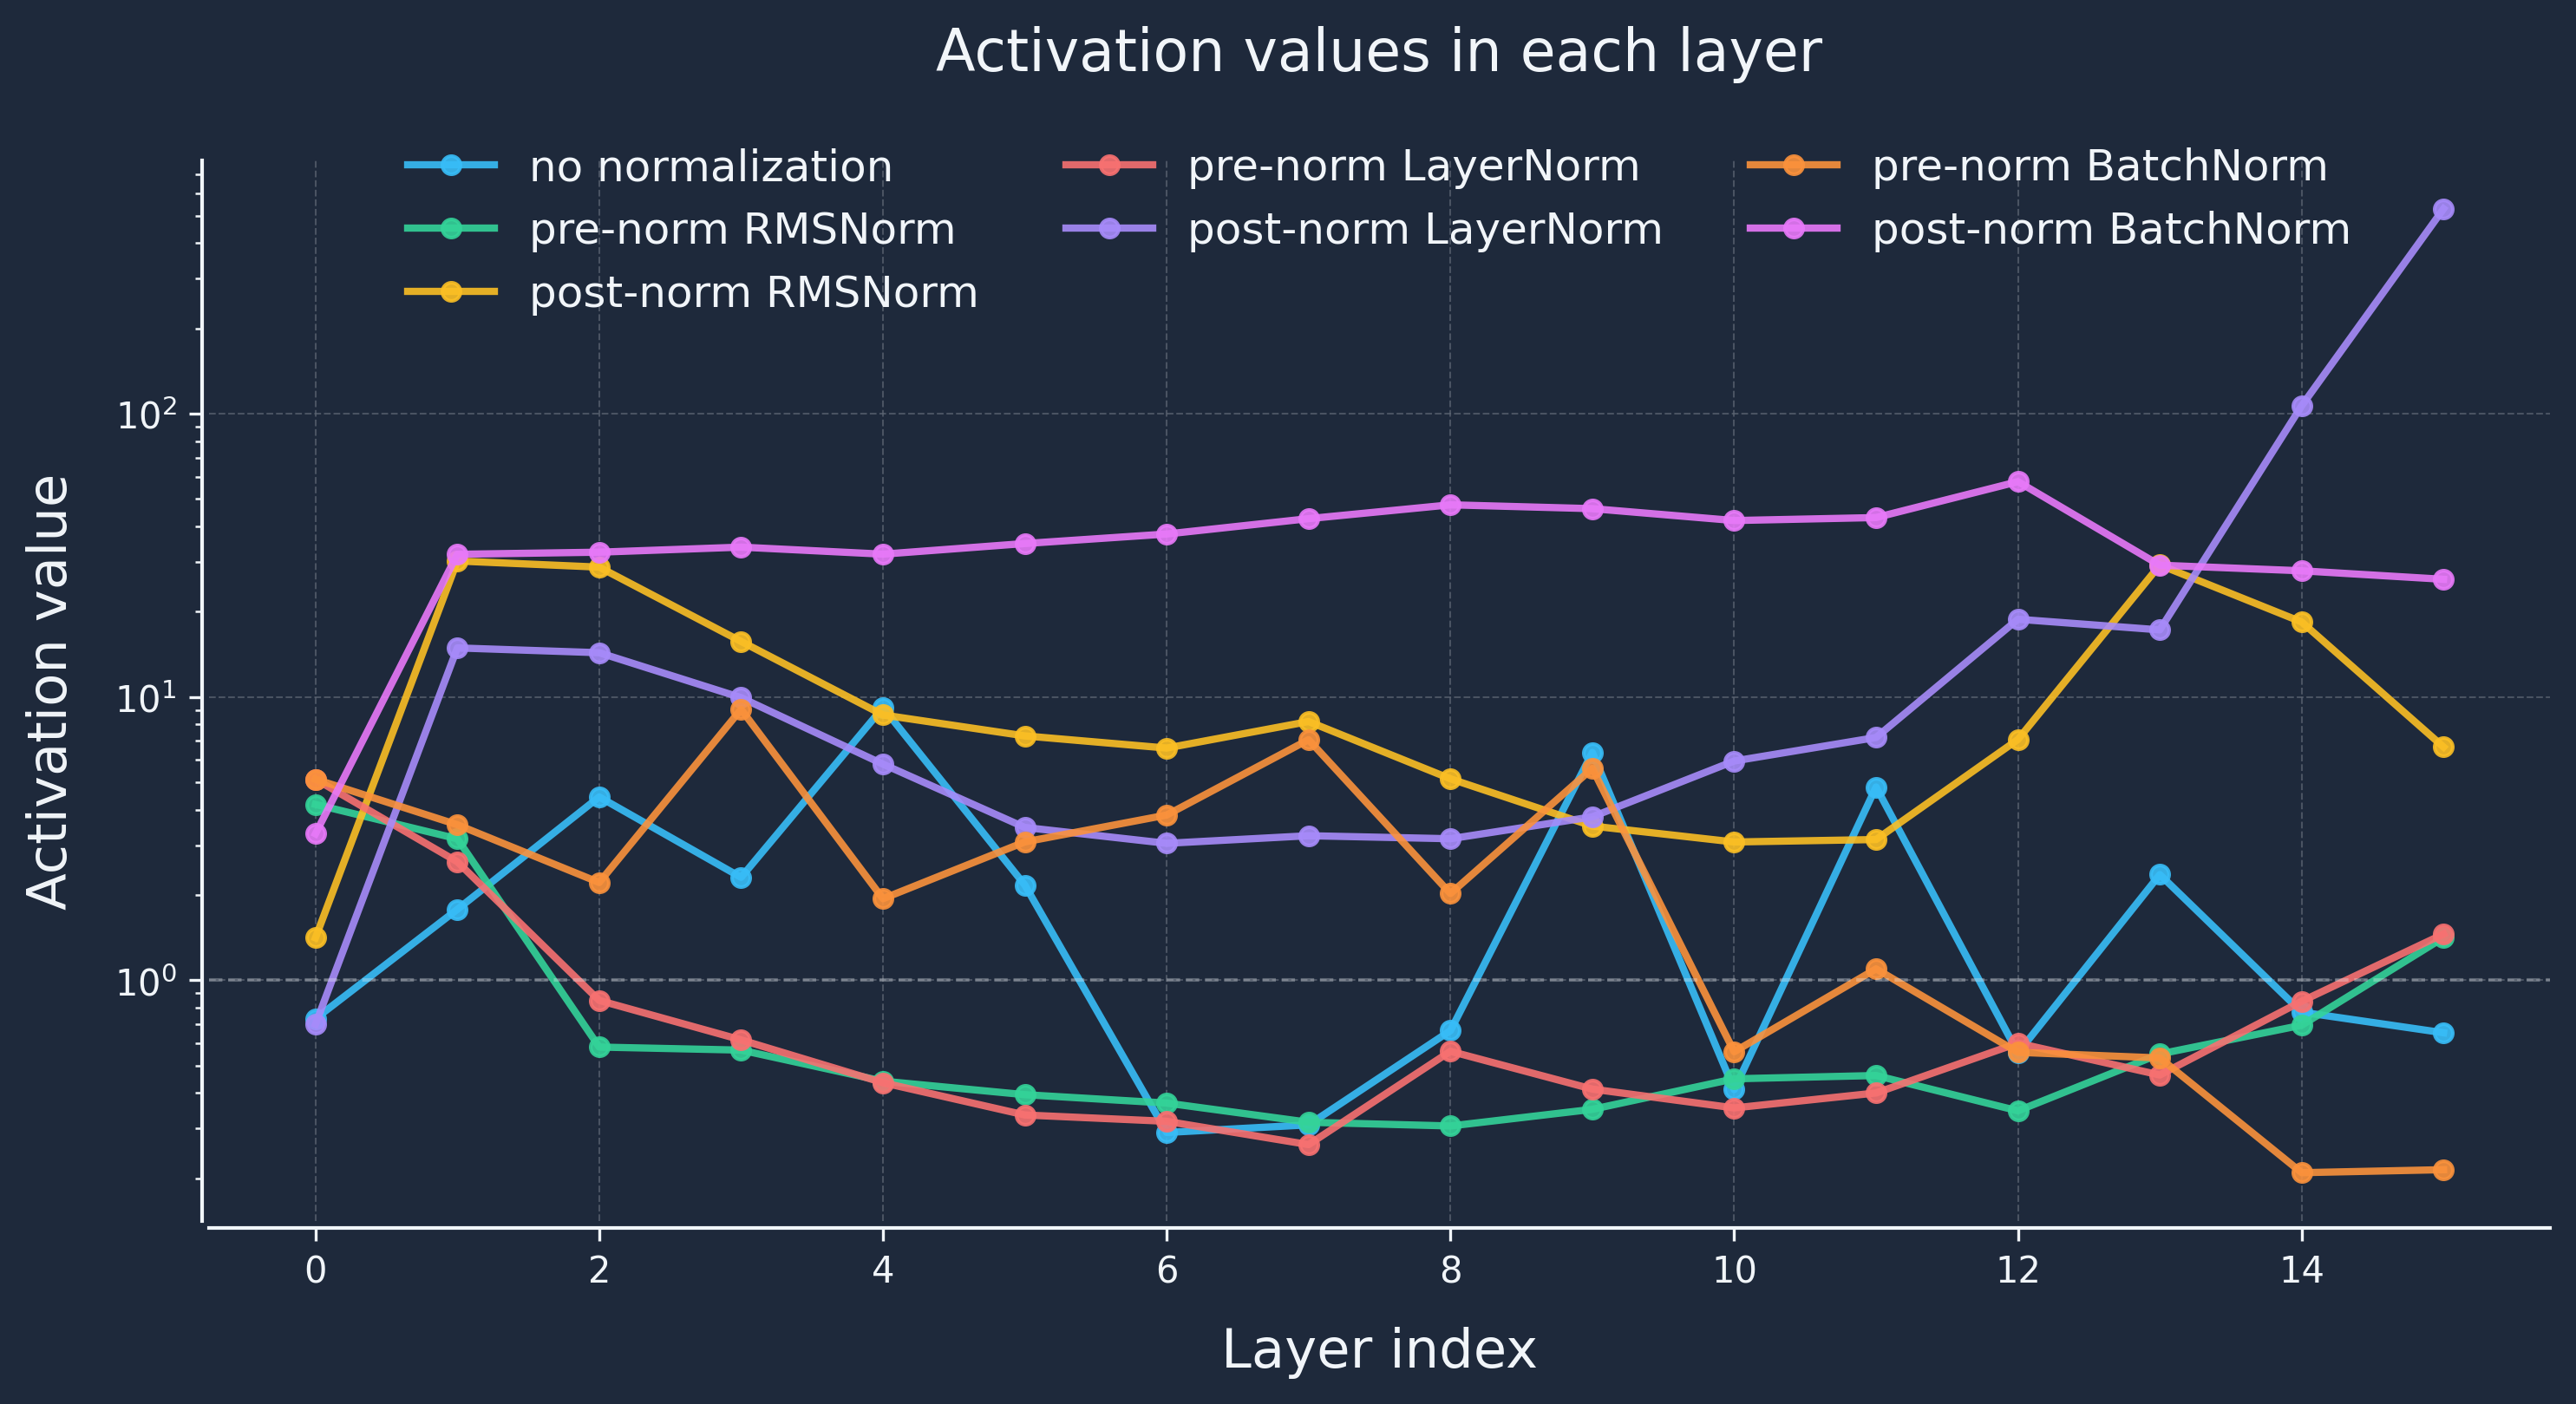

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import torch

# Prefer the deployment font when available, otherwise fall back to common sans-serif fonts
font_candidates = ['Inter', 'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['font.family'] = font_candidates
font_path = 'fonts/Inter-Regular.ttf'
try:
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
except Exception:
    pass

# Set styling for all text and lines
plt.rcParams['text.color'] = '#F1F5F9'
plt.rcParams['axes.labelcolor'] = '#F1F5F9'
plt.rcParams['xtick.color'] = '#F1F5F9'
plt.rcParams['ytick.color'] = '#F1F5F9'
plt.rcParams['axes.edgecolor'] = '#F1F5F9'

# Grid styling
plt.rcParams['grid.color'] = '#5D6674'
plt.rcParams['grid.alpha'] = 0.7

def _coplot_luminance_from_rgba(rgba):
    r, g, b = mcolors.to_rgb(rgba)
    def _linear(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * _linear(r) + 0.7152 * _linear(g) + 0.0722 * _linear(b)

def _coplot_text_color_for_rgba(rgba, preferred='#F1F5F9'):
    try:
        preferred_l = _coplot_luminance_from_rgba(mcolors.to_rgba(preferred))
        bg_l = _coplot_luminance_from_rgba(rgba)
        lighter = max(preferred_l, bg_l)
        darker = min(preferred_l, bg_l)
        ratio = (lighter + 0.05) / (darker + 0.05)
        if ratio >= 4.5:
            return preferred
    except Exception:
        pass
    bg_l = _coplot_luminance_from_rgba(rgba)
    return '#111111' if bg_l > 0.5 else '#FFFFFF'

# ── Signal survival per layer (post-hoc) ──
xb, yb = next(iter(test_loader))

# Create figure and axis with publication-quality settings
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)
fig.patch.set_facecolor('#1E293B')
ax.set_facecolor('#1E293B')

# Define distinct bright colors instead of the same blue, so lines are distinguishable
colors = ["#38BDF8", "#34D399", "#FBBF24", "#F87171", "#A78BFA", "#FB923C", "#E879F9"]
line_styles = ["-","--",":","-."]
marker_styles = ["o","s","^","D"]

for idx, run in enumerate(all_runs):
    model = run["model"].eval()
    if hasattr(model, "_orig_mod"):
        model = model._orig_mod

    magnitudes = []

    handles = []
    def make_hook(store):
        def hook(module, input, output):
            store.append(output.detach().abs().mean().item())
        return hook

    for block in model.layers:
        m = []
        magnitudes.append(m)
        handles.append(block.register_forward_hook(make_hook(m)))

    with torch.no_grad():
        model(xb)

    for h in handles:
        h.remove()

    layer_means = [m[0] for m in magnitudes]

    line_style = line_styles[idx % len(line_styles)] if False else '-'
    marker_style = marker_styles[idx % len(marker_styles)] if False else 'o'

    ax.plot(range(len(layer_means)), layer_means,
           color=colors[idx % len(colors)],
           linewidth=2,
           linestyle=line_style,
           marker=marker_style, markersize=5,
           label=run["name"],
           alpha=0.9)

ax.set_yscale("log")
ax.axhline(y=1.0, color="#F1F5F9", linestyle="--", alpha=0.3, linewidth=1)

# Customize axis labels
ax.set_xlabel('Layer index', fontsize=15, labelpad=10, color='#F1F5F9')
ax.set_ylabel('Activation value', fontsize=15, color='#F1F5F9', labelpad=10)
ax.set_title("Activation values in each layer", fontsize=16, color='#F1F5F9', pad=25)

# Add grid
ax.grid(axis='both', alpha=0.7, color='#5D6674', linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add legend
ax.legend(loc='upper center',
         bbox_to_anchor=(0.5, 1.05),
         frameon=False, fontsize=12, ncol=3)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_color('#F1F5F9')
ax.spines['left'].set_color('#F1F5F9')

# Adjust spine positions
ax.spines['left'].set_position(('outward', 2))
ax.spines['bottom'].set_position(('outward', 2))

# Tight layout
plt.tight_layout()

# Display the plot
plt.show()